✅ Model Accuracy: 98.25%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



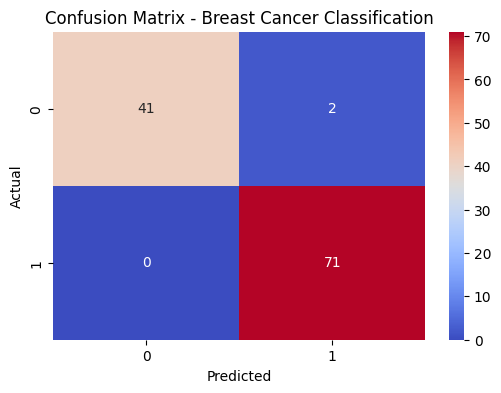

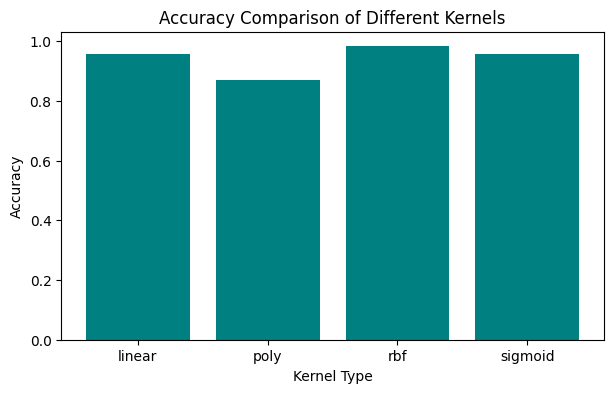

In [1]:
# 🧬 Breast Cancer Detection using SVM

# Step 1: Import Libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

# Step 3: Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 4: Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Train SVM Model
model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
model.fit(X_train_scaled, y_train)

# Step 6: Evaluate Model
y_pred = model.predict(X_test_scaled)

print(f"✅ Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Step 7: Visualize Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='coolwarm', fmt='d')
plt.title("Confusion Matrix - Breast Cancer Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 8: Try Different Kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
scores = []

for k in kernels:
    model = SVC(kernel=k, C=1, gamma='scale')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(7,4))
plt.bar(kernels, scores, color='teal')
plt.title('Accuracy Comparison of Different Kernels')
plt.xlabel('Kernel Type')
plt.ylabel('Accuracy')
plt.show()
